# Evrişimli Sinir Ağları (CNN) ile Görüntü Sınıflandırma (Fashion-MNIST)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, ReLU

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Eğitim verisi boyutu : ", X_train.shape)
print("Test verisi boyutu : ", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Eğitim verisi boyutu :  (60000, 28, 28)
Test verisi boyutu :  (10000, 28, 28)


In [ ]:
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

print("Yeni eğitim verisi boyutu : ", X_train.shape)
print("Yeni test verisi boyutu : ", X_test.shape)

Yeni eğitim verisi boyutu :  (60000, 28, 28, 1)
Yeni test verisi boyutu :  (10000, 28, 28, 1)


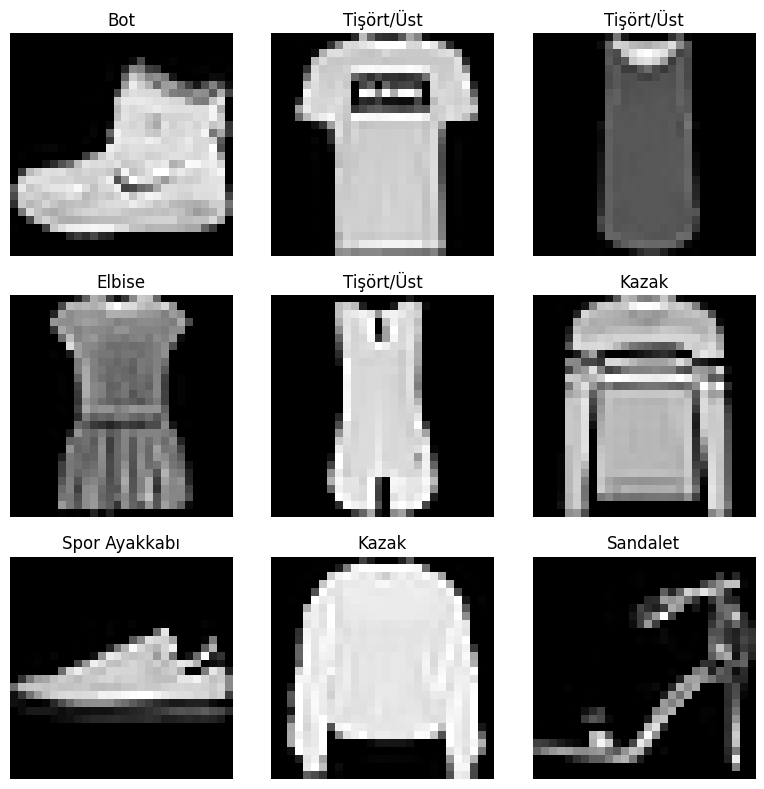

In [ ]:
class_names = ["Tişört/Üst", "Pantolon", "Kazak", "Elbise", "Mont",
               "Sandalet", "Gömlek", "Spor Ayakkabı", "Çanta", "Bot"]

plt.figure(figsize = (8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap = "gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation = "relu", input_shape = (28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3)),
    ReLU(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3)),
    ReLU(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation = "relu"),
    Dense(64, activation = "relu"),
    Dense(32, activation = "relu"),
    Dense(10, activation = "softmax"),
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 11, 11, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,850 (468.16 KB)

 Trainable params: 119,850 (468.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(optimizer = "adam",
                   loss = "sparse_categorical_crossentropy",
                   metrics = ["accuracy"])

In [ ]:
history = cnn_model.fit(X_train, y_train,
                         epochs = 10,
                         batch_size = 64,
                         validation_data = (X_test, y_test))

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7563 - loss: 0.6656 - val_accuracy: 0.8155 - val_loss: 0.5003
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8421 - loss: 0.4337 - val_accuracy: 0.8500 - val_loss: 0.4143
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8644 - loss: 0.3691 - val_accuracy: 0.8529 - val_loss: 0.3984
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8806 - loss: 0.3263 - val_accuracy: 0.8695 - val_loss: 0.3596
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8899 - loss: 0.2973 - val_accuracy: 0.8791 - val_loss: 0.3298
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8984 - loss: 0.2748 - val_accuracy: 0.8772 - val_loss: 0.3336
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9076 - loss: 0.2514 - val_accuracy: 0.8901 - val_loss: 0.3086
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9136 - loss: 0.2340 - val_accuracy: 0

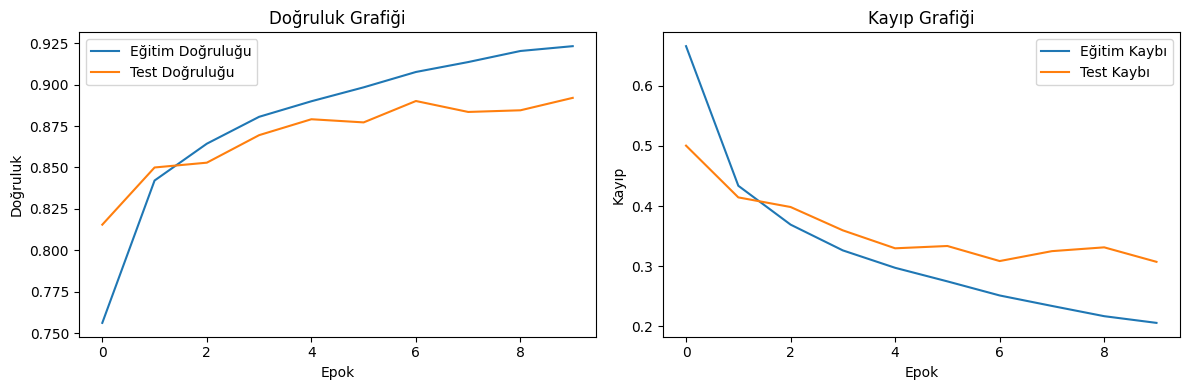

In [ ]:
plt.figure(figsize = (12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label = "Eğitim Doğruluğu")
plt.plot(history.history["val_accuracy"], label = "Test Doğruluğu")
plt.xlabel("Epok")
plt.ylabel("Doğruluk")
plt.legend()
plt.title("Doğruluk Grafiği")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label = "Eğitim Kaybı")
plt.plot(history.history["val_loss"], label = "Test Kaybı")
plt.xlabel("Epok")
plt.ylabel("Kayıp")
plt.legend()
plt.title("Kayıp Grafiği")

plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test)
print(f"Test doğruluğu : {test_accuracy:.4f}")
print(f"Test kaybı : {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8920 - loss: 0.3073
Test doğruluğu : 0.8920
Test kaybı : 0.3073


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


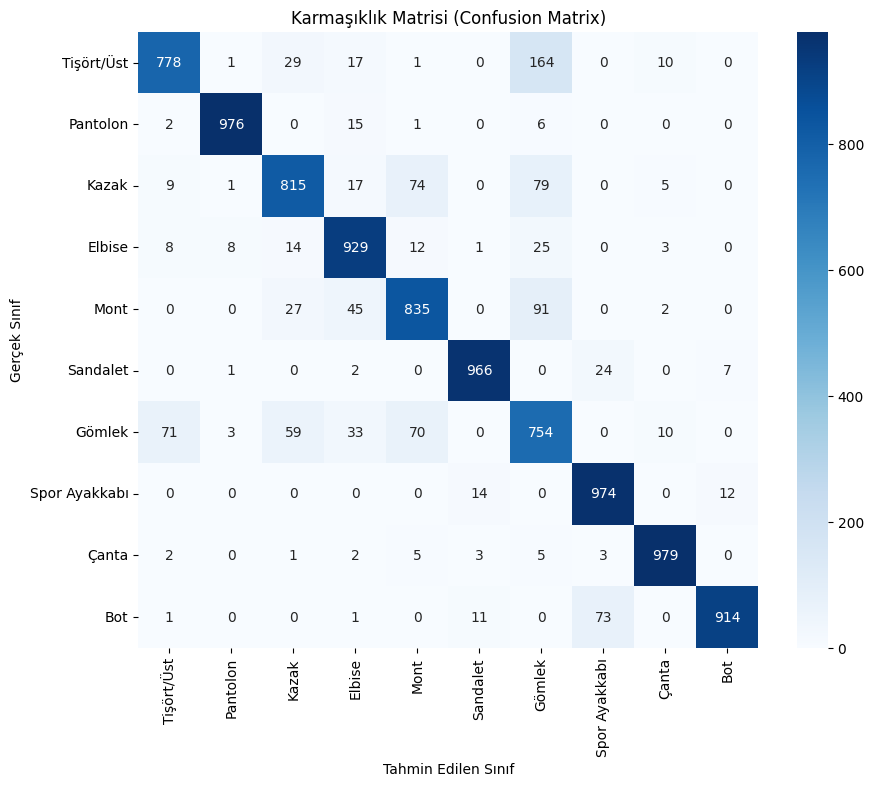

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_probs = cnn_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis = 1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (10, 8))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = class_names, yticklabels = class_names)
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.title("Karmaşıklık Matrisi (Confusion Matrix)")
plt.show()

In [ ]:
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)

print("En çok karıştırılan sınıf çiftleri:")
for i in range(3):
    idx = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)
    gercek, tahmin = idx
    print(f"Gerçek: {class_names[gercek]} -> Tahmin: {class_names[tahmin]} "
          f"({cm_copy[idx]} kez)")
    cm_copy[idx] = 0

En çok karıştırılan sınıf çiftleri:
Gerçek: Tişört/Üst -> Tahmin: Gömlek (164 kez)
Gerçek: Mont -> Tahmin: Gömlek (91 kez)
Gerçek: Kazak -> Tahmin: Gömlek (79 kez)
